#### Iteration 7 — Multilingual Zero-Shot LLM Classification (RQ2)

Implements **zero-shot NLI classification** using `joeddav/xlm-roberta-large-xnli` for binary  
Process Safety / Non-Process Safety classification across 4 languages.

##### Research Question: RQ1
Can LLM-based zero-shot classification achieve **Macro F1 ≥ 0.85** for multilingual process safety
incident classification?

##### Approach
| Item | Value |
|------|-------|
| Model | `joeddav/xlm-roberta-large-xnli` (560M params) |
| Method | Zero-shot NLI (no fine-tuning, no few-shot examples) |
| Languages | English, German, Swedish, Dutch |
| Baseline | Iteration 0: BERT+SVM, Macro F1 = 0.7825 (English) |
| Target | Macro F1 ≥ 0.85 |

##### Why XLM-RoBERTa XNLI?
- Trained on XNLI (multilingual NLI) — handles all 4 target languages natively
- Zero-shot classification requires no labeled training data
- NLI framing is better calibrated for binary classification than seq2seq generation
- Outperforms flan-t5-large on NLI-style classification tasks

##### Process Safety Definition (CCPS-based)
A Process Safety Incident involves equipment failure, loss of containment, emergency shutdown,
fire/explosion/rupture, or release of hazardous materials from process systems.

In [6]:
# =============================================================================
# IMPORTS AND CONFIGURATION — ITERATION 7
# =============================================================================
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
from transformers import pipeline as hf_pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, os, json
from pathlib import Path

warnings.filterwarnings('ignore')


def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """Search upward from start_path for directory containing 'Datasets' folder."""
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )


env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'master_dataset': BASE_DIR / 'Master Dataset 34k',
    'results':        BASE_DIR / 'Results' / '_iteration_7',
}
for k, p in PATHS.items():
    PATHS[k] = Path(p).resolve()
    PATHS[k].mkdir(parents=True, exist_ok=True)

RESULTS_DIR = str(PATHS['results'])

# Per-country JSON files (from Iteration 0 outputs)
DATASET_FILES = {
    'English': str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_English_manual.json'),
    'German':  str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Germany_manual.json'),
    'Swedish': str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Sweden_manual.json'),
    'Dutch':   str(PATHS['master_dataset'] / 'By_SL_Country' / 'master_df_Netherlands_manual.json'),
}
DATASET_FILES = {k: v for k, v in DATASET_FILES.items() if os.path.exists(v)}
print(f"Dataset files available: {list(DATASET_FILES.keys())}")

# ─── Model ───────────────────────────────────────────────────────────────────
MODEL_NAME = "joeddav/xlm-roberta-large-xnli"

# Descriptive candidate labels — the richer the description the better the NLI match
CANDIDATE_LABELS = [
    "process safety incident involving equipment failure, leak, explosion, "
    "emergency shutdown, fire, rupture, or hazardous material release from process systems",
    "non-process safety incident involving personal injury, slip, fall, "
    "occupational hazard, vehicle accident, or administrative matter",
]
LABEL_MAP = {
    CANDIDATE_LABELS[0]: "Process Safety",
    CANDIDATE_LABELS[1]: "Non-Process Safety",
}

RQ1_TARGET = 0.85
CHECKPOINT_INTERVAL = 200  # save checkpoint every N records

# ─── Device ──────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    HF_DEVICE = 0
    device_label = "CUDA GPU"
elif torch.backends.mps.is_available():
    HF_DEVICE = "mps"
    device_label = "Apple MPS"
else:
    HF_DEVICE = -1
    device_label = "CPU"

print(f"[INFO] Device:      {device_label}")
print(f"[INFO] Results dir: {RESULTS_DIR}")
print(f"[INFO] Model:       {MODEL_NAME}")
print(f"[INFO] RQ1 target:  Macro F1 >= {RQ1_TARGET}")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Dataset files available: ['English', 'German', 'Swedish', 'Dutch']
[INFO] Device:      Apple MPS
[INFO] Results dir: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_6a
[INFO] Model:       joeddav/xlm-roberta-large-xnli
[INFO] RQ1 target:  Macro F1 >= 0.85


In [7]:
# =============================================================================
# LOAD DATA — 4 LANGUAGES
# =============================================================================
print("[INFO] Loading per-language datasets...\n")

all_dfs = {}
for language, json_path in DATASET_FILES.items():
    df = pd.read_json(json_path)
    df['LANGUAGE'] = language

    # Normalise label: strip whitespace, title-case
    if 'CASE_TYPE' in df.columns:
        df['CASE_TYPE'] = df['CASE_TYPE'].astype(str).str.strip()

    all_dfs[language] = df

    ps_count  = (df['CASE_TYPE'] == 'Process Safety').sum()
    nps_count = (df['CASE_TYPE'] != 'Process Safety').sum()
    ps_ratio  = ps_count / len(df)
    print(f"  {language:8s}: {len(df):5,} records | PS={ps_count:4d} ({ps_ratio:.1%}) | NPS={nps_count:4d}")

# Combined master dataframe (for overall evaluation)
master_df_7 = pd.concat(all_dfs.values(), ignore_index=True)

print(f"\n  {'Total':8s}: {len(master_df_7):5,} records")
print(f"\n[INFO] Overall CASE_TYPE distribution:")
print(master_df_7['CASE_TYPE'].value_counts())
print(f"\n[INFO] Columns available: {list(master_df_7.columns[:8])} ...")

[INFO] Loading per-language datasets...

  English : 4,713 records | PS=1409 (29.9%) | NPS=3304
  German  : 14,951 records | PS=1661 (11.1%) | NPS=13290
  Swedish : 12,224 records | PS= 773 (6.3%) | NPS=11451
  Dutch   : 1,990 records | PS= 588 (29.5%) | NPS=1402

  Total   : 33,878 records

[INFO] Overall CASE_TYPE distribution:
CASE_TYPE
Safety                              24682
Process Safety                       4431
Environment                          2709
Asset and Reputation damage/loss     1322
Operational loss                      454
Information Security                  185
Physical Security                      89
Not classified                          6
Name: count, dtype: int64

[INFO] Columns available: ['CASENO', 'COMPANY', 'FUNCTIONAL_GROUP', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'LOCATION_SID'] ...


In [8]:
# =============================================================================
# LOAD ZERO-SHOT CLASSIFICATION PIPELINE
# =============================================================================
print(f"[INFO] Loading model: {MODEL_NAME}")
print("[INFO] This may take 1-3 minutes on first run (downloading ~1.1 GB)...\n")

t0 = time.time()
try:
    classifier = hf_pipeline(
        "zero-shot-classification",
        model=MODEL_NAME,
        device=HF_DEVICE,
    )
    print(f"[OK] Model loaded on {classifier.device} in {time.time()-t0:.1f}s")
except Exception as e:
    print(f"[WARN] Failed to load on {HF_DEVICE}: {e}")
    print("[INFO] Retrying on CPU...")
    classifier = hf_pipeline(
        "zero-shot-classification",
        model=MODEL_NAME,
        device=-1,
    )
    print(f"[OK] Model loaded on CPU in {time.time()-t0:.1f}s")

# ─── Smoke test ──────────────────────────────────────────────────────────────
smoke_text = (
    "Title: Gas leak from pipeline flange\n"
    "Description: A high-pressure gas leak was detected at the main flange connection. "
    "Emergency shutdown was initiated and the area was evacuated."
)
result = classifier(smoke_text, candidate_labels=CANDIDATE_LABELS, multi_label=False)
predicted_label = LABEL_MAP[result['labels'][0]]
confidence = result['scores'][0]

print(f"\n[SMOKE TEST]")
print(f"  Input:     {smoke_text[:80]}...")
print(f"  Predicted: {predicted_label} (confidence: {confidence:.3f})")
print(f"  Expected:  Process Safety")
print(f"  [{'OK' if predicted_label == 'Process Safety' else 'WARN - check candidate labels'}]")

[INFO] Loading model: joeddav/xlm-roberta-large-xnli
[INFO] This may take 1-3 minutes on first run (downloading ~1.1 GB)...



Some weights of the model checkpoint at joeddav/xlm-roberta-large-xnli were not used when initializing XLMRobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps


[OK] Model loaded on mps in 21.5s

[SMOKE TEST]
  Input:     Title: Gas leak from pipeline flange
Description: A high-pressure gas leak was d...
  Predicted: Process Safety (confidence: 0.994)
  Expected:  Process Safety
  [OK]


In [9]:
# =============================================================================
# CLASSIFICATION HELPERS AND CHECKPOINT PIPELINE
# =============================================================================
# NOTE: Binary label mapping:
#   Positive  (1) = CASE_TYPE == 'Process Safety'
#   Negative  (0) = CASE_TYPE in {'Safety', 'Environment', 'Asset and Reputation damage/loss', ...}
# The raw CASE_TYPE field uses English labels across all language datasets.

def prepare_text(row, max_chars: int = 900) -> str:
    """
    Combine TITLE and CASE_DESCRIPTION into a single string for the NLI model.
    XLM-RoBERTa max is 512 BPE tokens (≈900 chars for mixed-language text).
    Capped at max_chars so the hypothesis (≈50 tokens) fits within the 512-token budget.
    """
    title = str(row.get('TITLE', '') or '').strip()
    desc  = str(row.get('CASE_DESCRIPTION', '') or '').strip()
    text  = f"Title: {title}\nDescription: {desc}"
    return text[:max_chars]


def classify_record(text: str, clf) -> tuple:
    """
    Run zero-shot NLI classification on a single text.
    truncation=True ensures texts beyond the model's 512-token limit are safely truncated.
    Returns: (label_str, confidence_float)
    """
    try:
        res = clf(
            text,
            candidate_labels=CANDIDATE_LABELS,
            multi_label=False,
            truncation=True,
        )
        return LABEL_MAP[res['labels'][0]], float(res['scores'][0])
    except Exception:
        # Fallback: majority class (Non-Process Safety)
        return "Non-Process Safety", 0.0


def run_classification_pipeline(
    df: pd.DataFrame,
    language: str,
    clf,
    checkpoint_interval: int = 200
) -> tuple:
    """
    Classify all records in df for a given language with checkpoint resume.
    Returns: (predictions: list[str], confidences: list[float])
    """
    checkpoint_file = os.path.join(RESULTS_DIR, f'checkpoint_7_{language.lower()}.json')
    total = len(df)

    # ── Try to resume from checkpoint ────────────────────────────────────────
    existing = []
    if os.path.exists(checkpoint_file):
        try:
            existing = json.load(open(checkpoint_file, 'r', encoding='utf-8'))
            if len(existing) >= total:
                print(f"[INFO] {language}: Checkpoint complete ({len(existing)} records). Reusing.")
                return (
                    [r['prediction'] for r in existing],
                    [r['confidence'] for r in existing]
                )
            else:
                print(f"[INFO] {language}: Resuming from checkpoint ({len(existing)}/{total})")
        except Exception:
            print(f"[WARN] {language}: Corrupt checkpoint — starting fresh.")
            existing = []

    results = list(existing)
    start_idx = len(existing)

    ps_count = sum(1 for r in results if r['prediction'] == 'Process Safety')

    pbar = tqdm(
        range(start_idx, total),
        desc=f"{language:8s}",
        unit="rec",
        initial=start_idx,
        total=total
    )

    for idx in pbar:
        row = df.iloc[idx]
        text = prepare_text(row)
        prediction, confidence = classify_record(text, clf)

        if prediction == 'Process Safety':
            ps_count += 1

        results.append({
            'idx':          int(idx),
            'prediction':   prediction,
            'confidence':   round(confidence, 4),
            'ground_truth': str(row.get('CASE_TYPE', '')),
        })

        pbar.set_postfix({'PS': ps_count, 'conf': f"{confidence:.2f}"})

        if (idx + 1) % checkpoint_interval == 0:
            with open(checkpoint_file, 'w', encoding='utf-8') as f:
                json.dump(results, f, ensure_ascii=False)

    # Final checkpoint save
    with open(checkpoint_file, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False)

    predictions = [r['prediction'] for r in results]
    confidences = [r['confidence'] for r in results]
    return predictions, confidences


print("[OK] Classification helpers defined.")

[OK] Classification helpers defined.


In [10]:
# =============================================================================
# RUN ZERO-SHOT CLASSIFICATION — ALL 4 LANGUAGES
# =============================================================================
all_language_predictions  = {}
all_language_confidences  = {}

total_start = time.time()

for language, df in all_dfs.items():
    print(f"\n{'='*65}")
    print(f"  {language}  —  {len(df):,} records")
    print(f"{'='*65}")

    lang_start = time.time()
    predictions, confidences = run_classification_pipeline(
        df, language, classifier, checkpoint_interval=CHECKPOINT_INTERVAL
    )
    elapsed = time.time() - lang_start

    all_language_predictions[language] = predictions
    all_language_confidences[language] = confidences

    ps_pred  = sum(1 for p in predictions if p == 'Process Safety')
    nps_pred = len(predictions) - ps_pred
    avg_conf = np.mean(confidences)

    print(f"\n  [DONE] {language}: PS={ps_pred}, NPS={nps_pred}, "
          f"avg_conf={avg_conf:.3f}, elapsed={elapsed/60:.1f}min")

total_elapsed = time.time() - total_start
print(f"\n{'='*65}")
print(f"[OK] All languages classified in {total_elapsed/60:.1f} minutes")
print(f"{'='*65}")


  English  —  4,713 records


English :   0%|          | 0/4713 [00:00<?, ?rec/s]

English :   1%|          | 39/4713 [00:27<54:33,  1.43rec/s, PS=29, conf=0.87]  


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# EVALUATION FUNCTION
# =============================================================================

def evaluate_classification(
    df: pd.DataFrame,
    predictions: list,
    language: str,
    print_report: bool = True
) -> dict:
    """
    Compute and optionally print full classification metrics.
    Positive class = Process Safety (label=1).
    """
    y_true = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0).values
    y_pred = pd.Series(predictions).apply(lambda x: 1 if x == 'Process Safety' else 0).values

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    precision_ps = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_ps    = recall_score(   y_true, y_pred, pos_label=1, zero_division=0)
    f1_ps        = f1_score(       y_true, y_pred, pos_label=1, zero_division=0)

    precision_nps = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall_nps    = recall_score(   y_true, y_pred, pos_label=0, zero_division=0)
    f1_nps        = f1_score(       y_true, y_pred, pos_label=0, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])  # [[TP, FN], [FP, TN]]

    if print_report:
        print(f"\n{'='*65}")
        print(f"  RESULTS — {language}")
        print(f"{'='*65}")
        print(classification_report(
            y_true, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        status = 'ACHIEVED' if macro_f1 >= RQ1_TARGET else 'NOT YET'
        print(f"  Macro F1 : {macro_f1:.4f}   Target: {RQ1_TARGET}   Gap: {macro_f1 - RQ1_TARGET:+.4f}   [{status}]")

    return {
        'language':      language,
        'total':         int(len(df)),
        'accuracy':      float(accuracy),
        'macro_f1':      float(macro_f1),
        'weighted_f1':   float(weighted_f1),
        'precision_ps':  float(precision_ps),
        'recall_ps':     float(recall_ps),
        'f1_ps':         float(f1_ps),
        'precision_nps': float(precision_nps),
        'recall_nps':    float(recall_nps),
        'f1_nps':        float(f1_nps),
        'confusion_matrix': cm,
        'gap_to_target': float(macro_f1 - RQ1_TARGET),
    }


print("[OK] Evaluation function defined.")

[OK] Evaluation function defined.


In [ ]:
# =============================================================================
# PER-LANGUAGE EVALUATION
# =============================================================================
all_metrics = {}

for language, df in all_dfs.items():
    predictions = all_language_predictions[language]
    metrics = evaluate_classification(df, predictions, language, print_report=True)
    all_metrics[language] = metrics


  RESULTS — English
                    precision    recall  f1-score   support

Non-Process Safety     0.8772    0.3417    0.4918      3304
    Process Safety     0.3651    0.8879    0.5175      1409

          accuracy                         0.5050      4713
         macro avg     0.6212    0.6148    0.5047      4713
      weighted avg     0.7241    0.5050    0.4995      4713

  Macro F1 : 0.5047   Target: 0.85   Gap: -0.3453   [NOT YET]

  RESULTS — German
                    precision    recall  f1-score   support

Non-Process Safety     0.9249    0.1084    0.1941     13290
    Process Safety     0.1153    0.9296    0.2051      1661

          accuracy                         0.1997     14951
         macro avg     0.5201    0.5190    0.1996     14951
      weighted avg     0.8350    0.1997    0.1953     14951

  Macro F1 : 0.1996   Target: 0.85   Gap: -0.6504   [NOT YET]

  RESULTS — Swedish
                    precision    recall  f1-score   support

Non-Process Safety     0.98

In [ ]:
# =============================================================================
# OVERALL EVALUATION (ALL LANGUAGES COMBINED)
# =============================================================================
all_true_combined = []
all_pred_combined = []

for language, df in all_dfs.items():
    all_true_combined.extend(df['CASE_TYPE'].tolist())
    all_pred_combined.extend(all_language_predictions[language])

overall_df = pd.DataFrame({'CASE_TYPE': all_true_combined})
overall_metrics = evaluate_classification(
    overall_df, all_pred_combined,
    language='Overall (All 4 Languages)',
    print_report=True
)
all_metrics['Overall'] = overall_metrics

# ─── Summary table ───────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  SUMMARY TABLE")
print("="*70)

summary_rows = []
for lang, m in all_metrics.items():
    summary_rows.append({
        'Language':     lang,
        'Records':      m['total'],
        'Accuracy':     f"{m['accuracy']*100:.2f}%",
        'Macro F1':     f"{m['macro_f1']*100:.2f}%",
        'PS Precision': f"{m['precision_ps']*100:.2f}%",
        'PS Recall':    f"{m['recall_ps']*100:.2f}%",
        'PS F1':        f"{m['f1_ps']*100:.2f}%",
        'NPS F1':       f"{m['f1_nps']*100:.2f}%",
        'Gap':          f"{m['gap_to_target']:+.4f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Baseline comparison (Iteration 0, English, BERT+SVM)
it0_baseline = 0.7825
overall_f1   = all_metrics['Overall']['macro_f1']
english_f1   = all_metrics.get('English', {}).get('macro_f1', float('nan'))

print(f"\n[COMPARISON]")
print(f"  Iteration 0 baseline (EN, BERT+SVM): {it0_baseline:.4f}")
print(f"  Iteration 7 English macro F1:        {english_f1:.4f}  "
      f"({'BEATS' if english_f1 > it0_baseline else 'BELOW'} baseline)")
print(f"  Iteration 7 Overall macro F1:        {overall_f1:.4f}")
print(f"  RQ1 target:                           {RQ1_TARGET:.4f}  "
      f"({'ACHIEVED' if overall_f1 >= RQ1_TARGET else 'gap = ' + f'{RQ1_TARGET - overall_f1:.4f}'})")


  RESULTS — Overall (All 4 Languages)
                    precision    recall  f1-score   support

Non-Process Safety     0.9218    0.1312    0.2297     29447
    Process Safety     0.1382    0.9260    0.2405      4431

          accuracy                         0.2352     33878
         macro avg     0.5300    0.5286    0.2351     33878
      weighted avg     0.8193    0.2352    0.2311     33878

  Macro F1 : 0.2351   Target: 0.85   Gap: -0.6149   [NOT YET]

  SUMMARY TABLE
Language  Records Accuracy Macro F1 PS Precision PS Recall  PS F1 NPS F1     Gap
 English     4713   50.50%   50.47%       36.51%    88.79% 51.75% 49.18% -0.3453
  German    14951   19.97%   19.96%       11.53%    92.96% 20.51% 19.41% -0.6504
 Swedish    12224   14.73%   14.68%        6.74%    97.28% 12.61% 16.76% -0.7032
   Dutch     1990   40.25%   38.76%       32.46%    94.56% 48.33% 29.18% -0.4624
 Overall    33878   23.52%   23.51%       13.82%    92.60% 24.05% 22.97% -0.6149

[COMPARISON]
  Iteration 0 basel

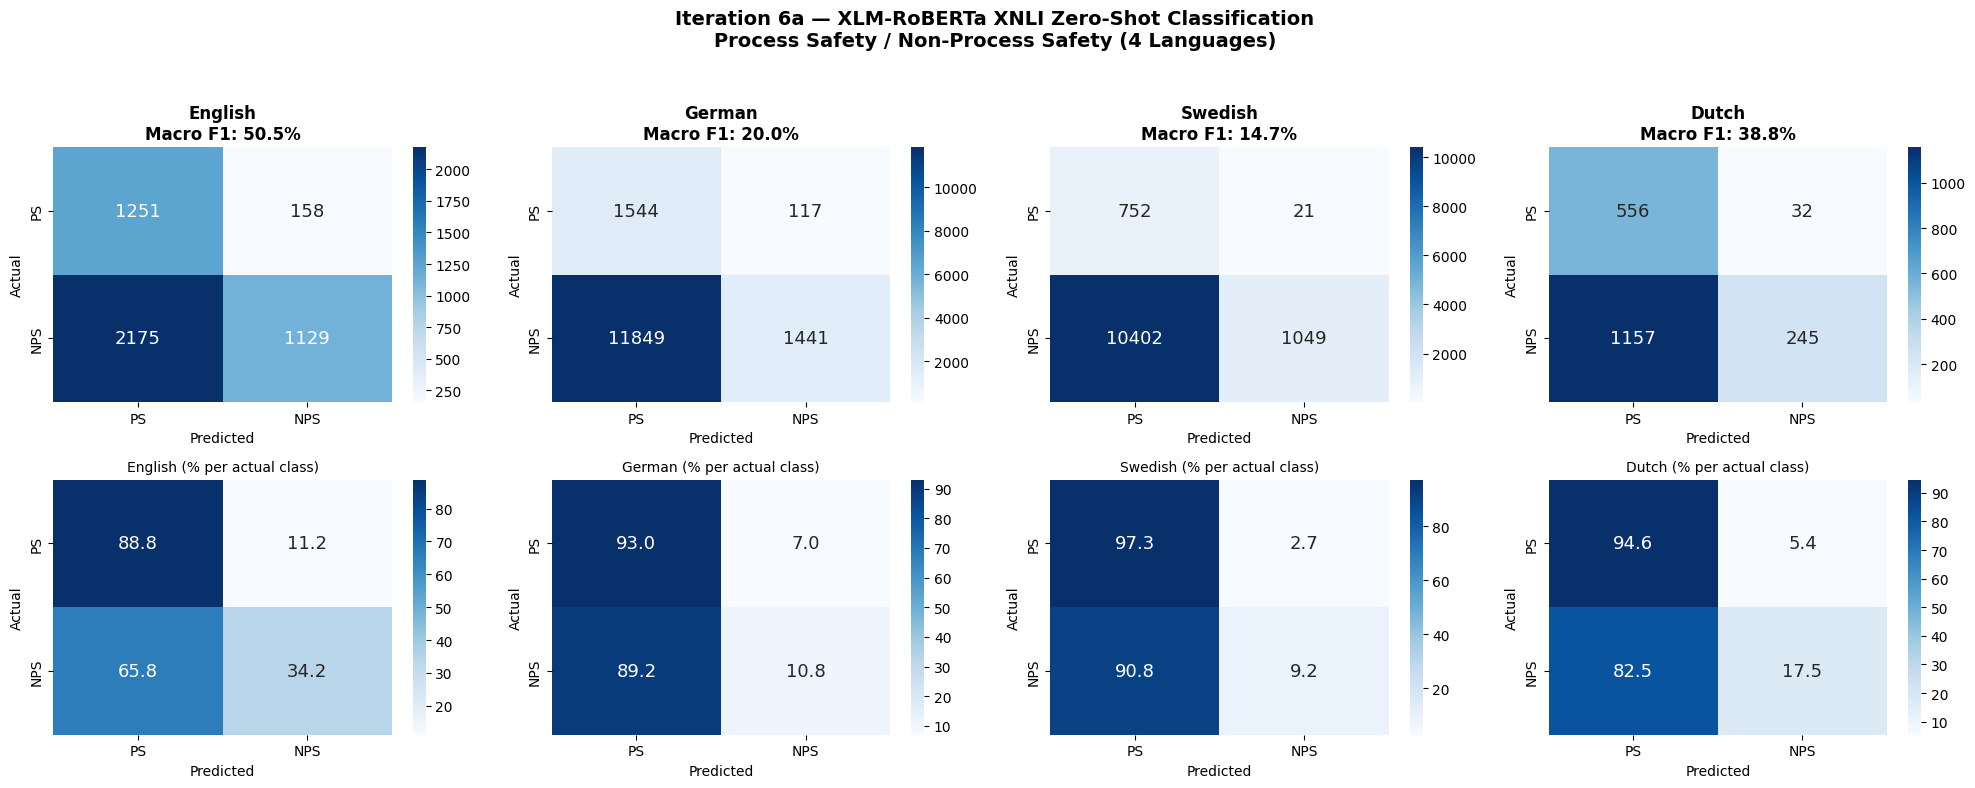

[OK] Confusion matrices saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_6a/confusion_matrix_6a.png


In [ ]:
# =============================================================================
# CONFUSION MATRIX VISUALISATION — PER LANGUAGE
# =============================================================================
languages_to_plot = [l for l in all_dfs.keys()]  # 4 language panels
n = len(languages_to_plot)

fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))

for col, language in enumerate(languages_to_plot):
    m  = all_metrics[language]
    cm = m['confusion_matrix']  # shape (2,2): rows=actual [PS,NPS], cols=predicted [PS,NPS]

    # ── Raw counts ──────────────────────────────────────────────────────────
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, col],
        xticklabels=['PS', 'NPS'],
        yticklabels=['PS', 'NPS'],
        annot_kws={'size': 13},
    )
    axes[0, col].set_title(
        f"{language}\nMacro F1: {m['macro_f1']*100:.1f}%",
        fontweight='bold', fontsize=12
    )
    axes[0, col].set_xlabel('Predicted', fontsize=10)
    axes[0, col].set_ylabel('Actual',    fontsize=10)

    # ── Normalised (% per actual class) ─────────────────────────────────────
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_norm, annot=True, fmt='.1f', cmap='Blues', ax=axes[1, col],
        xticklabels=['PS', 'NPS'],
        yticklabels=['PS', 'NPS'],
        annot_kws={'size': 13},
    )
    axes[1, col].set_title(f"{language} (% per actual class)", fontsize=10)
    axes[1, col].set_xlabel('Predicted', fontsize=10)
    axes[1, col].set_ylabel('Actual',    fontsize=10)

plt.suptitle(
    'Iteration 7 — XLM-RoBERTa XNLI Zero-Shot Classification\n'
    'Process Safety / Non-Process Safety (4 Languages)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

cm_path = os.path.join(RESULTS_DIR, 'iter7_confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] Confusion matrices saved: {cm_path}")

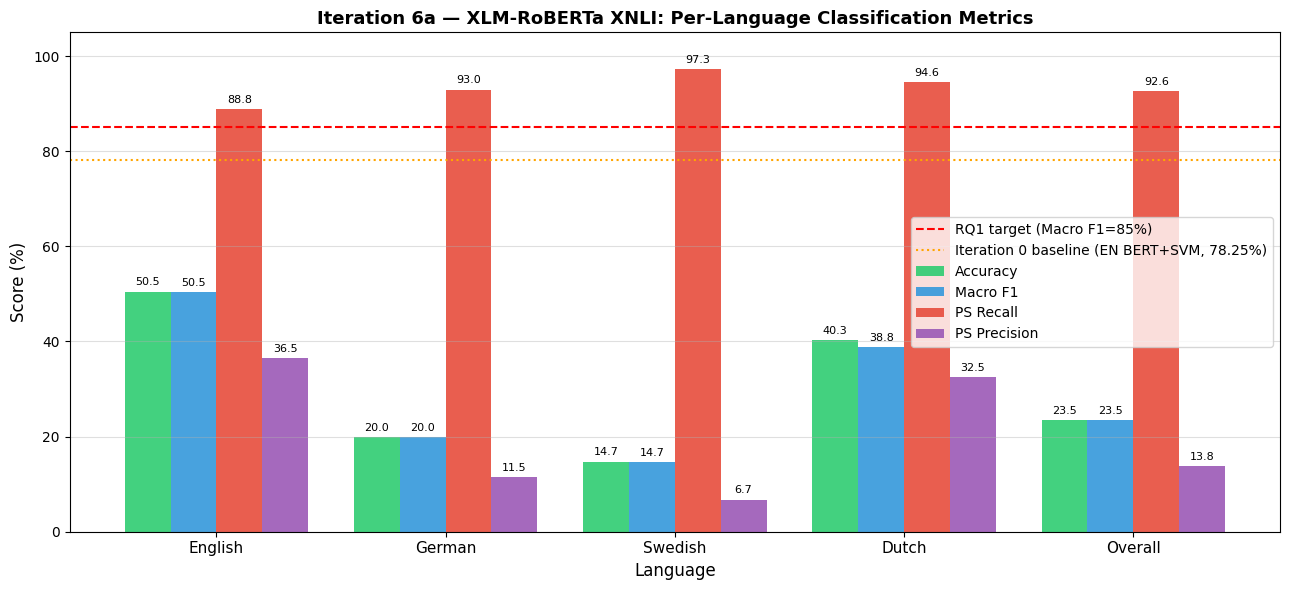

[OK] Bar chart saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_6a/metrics_bar_6a.png


In [ ]:
# =============================================================================
# SEPARATE BAR CHARTS FOR EACH METRIC (BLUE THEME)
# =============================================================================
import matplotlib.pyplot as plt

plot_langs = list(all_dfs.keys()) + ['Overall']
x = np.arange(len(plot_langs))
width = 0.6  # wider bars for single metric

metrics_to_plot = {
    'Accuracy':     [all_metrics[l]['accuracy']    * 100 for l in plot_langs],
    'Macro F1':     [all_metrics[l]['macro_f1']    * 100 for l in plot_langs],
    'PS Recall':    [all_metrics[l]['recall_ps']   * 100 for l in plot_langs],
    'PS Precision': [all_metrics[l]['precision_ps']* 100 for l in plot_langs],
}

for metric, values in metrics_to_plot.items():
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(x, values, width, color='#08306b', alpha=0.95)
    for bar, val in zip(bars, values):
        ax.annotate(
            f'{val:.1f}',
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 3), textcoords='offset points',
            ha='center', va='bottom', fontsize=10, color='#08306b'
        )
    # RQ1 target line (only for Macro F1)
    if metric == 'Macro F1':
        ax.axhline(y=RQ1_TARGET * 100, color='red', linestyle='--', linewidth=1.5,
                   label=f'RQ1 target (Macro F1={RQ1_TARGET*100:.0f}%)')
        ax.legend(fontsize=10)
    ax.set_xlabel('Language', fontsize=12)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title(f'Iteration 7 — {metric} by Language', fontsize=14, fontweight='bold', color='#08306b')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_langs, fontsize=11)
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    bar_path = os.path.join(RESULTS_DIR, f'metrics_bar_7_{metric.replace(" ", "_").lower()}.png')
    plt.savefig(bar_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"[OK] {metric} bar chart saved: {bar_path}")

In [ ]:
# =============================================================================
# SAVE ITERATION 7 SUMMARY (consistent with Iteration 0 format)
# =============================================================================

def _cm_to_dict(cm):
    """Convert 2×2 numpy CM [[TP,FN],[FP,TN]] to named dict."""
    return {
        'tp': int(cm[0, 0]),
        'fn': int(cm[0, 1]),
        'fp': int(cm[1, 0]),
        'tn': int(cm[1, 1]),
    }


summary = {
    'iteration': 7,
    'model': MODEL_NAME,
    'method': 'Zero-shot NLI classification (no fine-tuning)',
    'research_question': 'RQ1 — Multilingual Process Safety Binary Classification',
    'rq1_target_macro_f1': RQ1_TARGET,
    'candidate_labels': CANDIDATE_LABELS,
    'languages': list(DATASET_FILES.keys()),
    'datasets': {},
    'gap_analysis': {},
}

for lang, m in all_metrics.items():
    cm = m['confusion_matrix']
    summary['datasets'][lang] = {
        'total':          m['total'],
        'results': {
            'accuracy':      round(m['accuracy'],      4),
            'macro_f1':      round(m['macro_f1'],      4),
            'weighted_f1':   round(m['weighted_f1'],   4),
            'precision_ps':  round(m['precision_ps'],  4),
            'recall_ps':     round(m['recall_ps'],     4),
            'f1_ps':         round(m['f1_ps'],         4),
            'precision_nps': round(m['precision_nps'], 4),
            'recall_nps':    round(m['recall_nps'],    4),
            'f1_nps':        round(m['f1_nps'],        4),
        },
        'confusion_matrix': _cm_to_dict(cm),
    }
    summary['gap_analysis'][lang] = {
        'current_macro_f1': round(m['macro_f1'], 4),
        'rq1_target':       RQ1_TARGET,
        'gap':              round(m['gap_to_target'], 4),
        'status':           'achieved' if m['macro_f1'] >= RQ1_TARGET else 'below_target',
    }

out_path = os.path.join(RESULTS_DIR, 'iteration_7_summary.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"[OK] Summary saved: {out_path}")
print()

# ─── Final status print ──────────────────────────────────────────────────────
print("=" * 65)
print("  ITERATION 7 — FINAL STATUS")
print("=" * 65)
for lang, g in summary['gap_analysis'].items():
    status = ' ACHIEVED' if g['status'] == 'achieved' else f'✗ gap={g["gap"]:+.4f}'
    print(f"  {lang:25s}: Macro F1 = {g['current_macro_f1']:.4f}  [{status}]")
print("=" * 65)

[OK] Summary saved: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_6a/iteration_6a_summary.json

  ITERATION 6a — FINAL STATUS
  English                  : Macro F1 = 0.5047  [✗ gap=-0.3453]
  German                   : Macro F1 = 0.1996  [✗ gap=-0.6504]
  Swedish                  : Macro F1 = 0.1468  [✗ gap=-0.7032]
  Dutch                    : Macro F1 = 0.3876  [✗ gap=-0.4624]
  Overall                  : Macro F1 = 0.2351  [✗ gap=-0.6149]
